In [31]:
import pandas as pd
import json

In [32]:
test_cases = [
    "request leave for 2 days due to personal reasons",
    "apply for software engineer job",
    "apologize for missing a deadline",
    "schedule a meeting with manager",
    "follow up after interview",
    "submit resignation professionally",
    "send project proposal to client",
    "remind client about pending payment",
    "request networking opportunity",
    "thank interviewer after interview"
]

In [33]:
def model_a(prompt):
    return f"Hi, I want to {prompt}. Please consider. Thanks."

In [34]:
def model_b(prompt):
    return f"""
Subject: {prompt.title()}

Dear Sir/Madam,

I hope you are doing well.

I am writing to {prompt}. I would like to formally request your consideration regarding this matter.

I assure you that I will handle all responsibilities accordingly and ensure smooth workflow.

Please let me know if any additional details are required.

Thank you for your time and support.

Sincerely,  
Sai Aneesh
"""

In [35]:
def evaluate_response(response):
    # Length
    length_score = min(len(response) / 80, 5)

    # Structure
    structure_score = 0
    if "Subject" in response:
        structure_score += 0.4
    if "Dear" in response:
        structure_score += 0.3
    if "Sincerely" in response or "Best regards" in response:
        structure_score += 0.3

    #  Improved Clarity
    sentences = [s for s in response.split('.') if s.strip() != ""]
    clarity_score = min(len(sentences) / 2, 5)

    return {
        "length": round(length_score, 2),
        "structure": round(structure_score, 2),
        "clarity": round(clarity_score, 2)
    }

In [36]:
results = []

for test in test_cases:
    res_a = model_a(test)
    res_b = model_b(test)

    score_a = evaluate_response(res_a)
    score_b = evaluate_response(res_b)

    results.append({
        "test_case": test,
        "model_a_output": res_a,
        "model_b_output": res_b,
        "model_a_scores": score_a,
        "model_b_scores": score_b
    })

In [37]:
rows = []

for r in results:
    rows.append({
        "test_case": r["test_case"],

        "A_length": r["model_a_scores"]["length"],
        "A_structure": r["model_a_scores"]["structure"],
        "A_clarity": r["model_a_scores"]["clarity"],

        "B_length": r["model_b_scores"]["length"],
        "B_structure": r["model_b_scores"]["structure"],
        "B_clarity": r["model_b_scores"]["clarity"]
    })

df = pd.DataFrame(rows)
df.to_csv("final_model_comparison.csv", index=False)

df

,test_case,A_length,A_structure,A_clarity,B_length,B_structure,B_clarity
0,request leave for 2 days due to personal reasons,1.10,0,1.5,5,1.0,3.5
1,apply for software engineer job,0.89,0,1.5,5,1.0,3.5
2,apologize for missing a deadline,0.90,0,1.5,5,1.0,3.5
3,schedule a meeting with manager,0.89,0,1.5,5,1.0,3.5
4,follow up after interview,0.81,0,1.5,5,1.0,3.5
5,submit resignation professionally,0.91,0,1.5,5,1.0,3.5
6,send project proposal to client,0.89,0,1.5,5,1.0,3.5
7,remind client about pending payment,0.94,0,1.5,5,1.0,3.5
8,request networking opportunity,0.88,0,1.5,5,1.0,3.5
9,thank interviewer after interview,0.91,0,1.5,5,1.0,3.5


In [38]:
with open("final_model_comparison.json", "w") as f:
    json.dump(results, f, indent=4)

In [39]:
avg_scores = {
    "Model A": {
        "length": round(df["A_length"].mean(), 2),
        "structure": round(df["A_structure"].mean(), 2),
        "clarity": round(df["A_clarity"].mean(), 2)
    },
    "Model B": {
        "length": round(df["B_length"].mean(), 2),
        "structure": round(df["B_structure"].mean(), 2),
        "clarity": round(df["B_clarity"].mean(), 2)
    }
}

print(avg_scores)

{'Model A': {'length': 0.91, 'structure': 0.0, 'clarity': 1.5}, 'Model B': {'length': 5.0, 'structure': 1.0, 'clarity': 3.5}}


In [40]:
analysis = f"""
MODEL COMPARISON ANALYSIS

1. Better Model:
The Structured Email Generator (Model B) significantly outperforms the Baseline Email Generator (Model A) across all evaluation metrics.
Model B achieves higher structure and clarity scores, demonstrating its effectiveness in generating professional emails.

2. Biggest Failure of Model A:
Model A fails to produce structured and professional email content.
It lacks essential components such as subject lines, greetings, and proper closing statements.

3. Recommendation:
Model B is strongly recommended for production use because:
- It generates complete and professional email formats
- It improves readability and clarity
- It follows standard communication practices

Overall, Model B provides higher quality outputs and is more suitable for real-world applications.

Average Scores:
{avg_scores}
"""

print(analysis)


MODEL COMPARISON ANALYSIS

1. Better Model:
The Structured Email Generator (Model B) significantly outperforms the Baseline Email Generator (Model A) across all evaluation metrics.
Model B achieves higher structure and clarity scores, demonstrating its effectiveness in generating professional emails.

2. Biggest Failure of Model A:
Model A fails to produce structured and professional email content.
It lacks essential components such as subject lines, greetings, and proper closing statements.

3. Recommendation:
Model B is strongly recommended for production use because:
- It generates complete and professional email formats
- It improves readability and clarity
- It follows standard communication practices

Overall, Model B provides higher quality outputs and is more suitable for real-world applications.

Average Scores:
{'Model A': {'length': 0.91, 'structure': 0.0, 'clarity': 1.5}, 'Model B': {'length': 5.0, 'structure': 1.0, 'clarity': 3.5}}



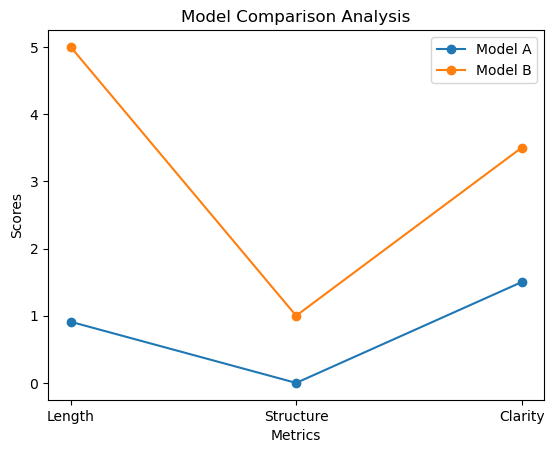

In [41]:
import matplotlib.pyplot as plt

labels = ["Length", "Structure", "Clarity"]

model_a_scores = [
    avg_scores["Model A"]["length"],
    avg_scores["Model A"]["structure"],
    avg_scores["Model A"]["clarity"]
]

model_b_scores = [
    avg_scores["Model B"]["length"],
    avg_scores["Model B"]["structure"],
    avg_scores["Model B"]["clarity"]
]

x = range(len(labels))

plt.figure()
plt.plot(x, model_a_scores, marker='o', label="Model A")
plt.plot(x, model_b_scores, marker='o', label="Model B")

plt.xticks(x, labels)
plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.title("Model Comparison Analysis")
plt.legend()

plt.savefig("model_comparison_graph.png")
plt.show()